# 🧬 GeneSight — Notebook 1: Data Pipeline
### ClinVar + gnomAD Variant Feature Engineering

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Bioinformatics-AI-Lab/genesight-biorag/blob/main/notebooks/01_GeneSight_Data_Pipeline.ipynb)

---

## What this notebook does

This is the foundation of **GeneSight** — a machine learning tool that predicts variant pathogenicity by combining labeled clinical data from [ClinVar](https://www.ncbi.nlm.nih.gov/clinvar/) with population frequency data from [gnomAD](https://gnomad.broadinstitute.org/).

**Pipeline steps:**
1. Download and parse the ClinVar variant summary (labeled ground truth)
2. Engineer biologically meaningful features from raw annotations
3. Fetch allele frequency data from gnomAD via their public API
4. Join and clean the final feature matrix
5. Export a clean `.parquet` file ready for model training (Notebook 2)

**Why ClinVar + gnomAD together?**
ClinVar tells us *what clinicians believe* about a variant (pathogenic/benign). gnomAD tells us *how common* a variant is in the general population — rare variants are enriched for pathogenicity. Combining both gives the model a much stronger signal than either source alone.

---

## ⚙️ Setup & Installations

In [2]:
# Install required packages
!pip install pandas pyarrow requests tqdm matplotlib seaborn --quiet
print("✅ Packages installed")

✅ Packages installed


In [3]:
import pandas as pd
import numpy as np
import requests
import gzip
import os
import time
import json
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Output directory
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

print("✅ Imports complete")
print(f"📁 Data directory: {DATA_DIR.resolve()}")

✅ Imports complete
📁 Data directory: /content/data


In [4]:
# ── Load shared config from repo ─────────────────────────────────────────────
import subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/Bioinformatics-AI-Lab/genesight-biorag.git"
REPO_DIR = Path("/content/genesight-biorag")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)],
                   check=True, capture_output=True)
    print("✅ Repo cloned")
else:
    subprocess.run(["git", "-C", str(REPO_DIR), "pull"], capture_output=True)
    print("✅ Repo updated")

sys.path.insert(0, str(REPO_DIR))
from config import *
make_dirs()
print(f"✅ Config loaded — {len(ALL_FEATURES)} features")
print(f"   Features: {ALL_FEATURES}")

✅ Repo updated
✅ Config loaded — 14 features
   Features: ['is_missense', 'is_synonymous', 'is_nonsense', 'is_splice', 'is_lof', 'is_frameshift', 'is_transition', 'chrom_encoded', 'num_submitters', 'review_confidence', 'log_af_genome', 'log_af_exome', 'pLI', 'LOEUF']


---
## 📥 Step 1: Download ClinVar Variant Summary

ClinVar provides a comprehensive flat-file download (`variant_summary.txt.gz`) updated monthly. Each row is a variant with:
- Genomic coordinates (chromosome, position, ref/alt alleles)
- Clinical significance label (our **prediction target**)
- Gene name, molecular consequence, review status

We filter to **single-nucleotide variants (SNVs)** with high-confidence review status (≥1 star) to ensure label quality.

In [5]:
CLINVAR_URL = "https://ftp.ncbi.nlm.nih.gov/pub/clinvar/tab_delimited/variant_summary.txt.gz"
CLINVAR_PATH = DATA_DIR / "variant_summary.txt.gz"

def download_with_progress(url, dest_path):
    """Download a file with a progress bar."""
    if dest_path.exists():
        print(f"⏭️  Already downloaded: {dest_path.name}")
        return
    print(f"⬇️  Downloading {dest_path.name}...")
    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    with open(dest_path, 'wb') as f, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            bar.update(len(chunk))
    print(f"✅ Saved to {dest_path}")

download_with_progress(CLINVAR_URL, CLINVAR_PATH)

⏭️  Already downloaded: variant_summary.txt.gz


In [6]:
# --- Inspect actual column names first (ClinVar schema changes with each release) ---
# NOTE: 'MolecularConsequence' was removed from variant_summary.txt in 2024.
# We now infer molecular consequence from the HGVS 'Name' column (see feature engineering).
print("🔍 Inspecting ClinVar column schema...")
with gzip.open(CLINVAR_PATH, 'rt', encoding='utf-8') as f:
    actual_cols = pd.read_csv(f, sep='\t', nrows=0).columns.tolist()
print(f"   Schema has {len(actual_cols)} columns")

# Desired columns — 'Name' contains HGVS notation used to infer consequence
DESIRED_COLS = [
    'GeneSymbol', 'Chromosome', 'Start', 'Stop', 'ReferenceAllele', 'AlternateAllele',
    'ClinicalSignificance', 'ReviewStatus', 'Type', 'Assembly',
    'NumberSubmitters', 'LastEvaluated', 'Name'
]
CLINVAR_COLS = [c for c in DESIRED_COLS if c in actual_cols]
missing = [c for c in DESIRED_COLS if c not in actual_cols]
if missing:
    print(f"   ⚠️  Columns not in this release (skipping): {missing}")
print(f"   ✅ Loading: {CLINVAR_COLS}")

print("\n📂 Parsing ClinVar variant summary...")
with gzip.open(CLINVAR_PATH, 'rt', encoding='utf-8') as f:
    clinvar_raw = pd.read_csv(f, sep='\t', usecols=CLINVAR_COLS, low_memory=False)

print(f"   Raw variants loaded: {len(clinvar_raw):,}")

# Filter: GRCh38, SNVs only, high-confidence labels
HIGH_CONFIDENCE_STATUSES = [
    'reviewed by expert panel',
    'criteria provided, multiple submitters, no conflicts',
    'criteria provided, single submitter'
]

clinvar = (
    clinvar_raw
    .query("Assembly == 'GRCh38'")
    .query("Type == 'single nucleotide variant'")
    .query("ReviewStatus in @HIGH_CONFIDENCE_STATUSES")
    .dropna(subset=['ClinicalSignificance', 'Chromosome', 'Start'])
    .copy()
)

print(f"   After filters (GRCh38, SNV, high-confidence): {len(clinvar):,}")

🔍 Inspecting ClinVar column schema...
   Schema has 43 columns
   ✅ Loading: ['GeneSymbol', 'Chromosome', 'Start', 'Stop', 'ReferenceAllele', 'AlternateAllele', 'ClinicalSignificance', 'ReviewStatus', 'Type', 'Assembly', 'NumberSubmitters', 'LastEvaluated', 'Name']

📂 Parsing ClinVar variant summary...
   Raw variants loaded: 8,981,173
   After filters (GRCh38, SNV, high-confidence): 3,648,462


✅ Label distribution:
   Benign (0):     1,258,088
   Pathogenic (1): 169,057
   Total:          1,427,145


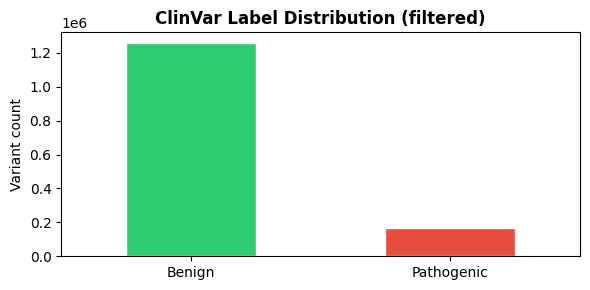

In [7]:
# Create binary label: Pathogenic=1, Benign=0
# We exclude ambiguous labels (VUS, conflicting) for a clean training signal
PATHOGENIC_TERMS = ['Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic']
BENIGN_TERMS     = ['Benign', 'Likely benign', 'Benign/Likely benign']

clinvar['label'] = np.where(
    clinvar['ClinicalSignificance'].isin(PATHOGENIC_TERMS), 1,
    np.where(clinvar['ClinicalSignificance'].isin(BENIGN_TERMS), 0, np.nan)
)
clinvar = clinvar.dropna(subset=['label'])
clinvar['label'] = clinvar['label'].astype(int)

label_counts = clinvar['label'].value_counts()
print(f"✅ Label distribution:")
print(f"   Benign (0):     {label_counts.get(0, 0):,}")
print(f"   Pathogenic (1): {label_counts.get(1, 0):,}")
print(f"   Total:          {len(clinvar):,}")

# Visualize
fig, ax = plt.subplots(figsize=(6, 3))
label_counts.rename({0: 'Benign', 1: 'Pathogenic'}).plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='white')
ax.set_title('ClinVar Label Distribution (filtered)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Variant count')
ax.tick_params(rotation=0)
plt.tight_layout()
plt.savefig(DATA_DIR / 'label_distribution.png', dpi=150)
plt.show()

---
## 🔧 Step 2: Feature Engineering from ClinVar Annotations

Raw variant annotations aren't directly usable by ML models. We engineer features that capture biological signal.

**Features used in the ML model (12 total):**

| Feature | Biological rationale |
|---|---|
| `is_missense` | Amino acid change — enriched for pathogenicity vs synonymous |
| `is_synonymous` | Silent mutation — usually benign, useful as contrast signal |
| `is_nonsense` | Stop-gain — typically loss-of-function, often pathogenic |
| `is_splice` | Disrupts splicing — can cause LoF or altered isoforms |
| `is_lof` | Combined LoF flag (nonsense OR frameshift) |
| `is_frameshift` | Reading frame disruption — usually pathogenic |
| `is_transition` | A↔G or C↔T substitution — transitions are more common and slightly less severe |
| `chrom_encoded` | Chromosome identity — some chromosomes are enriched for disease-relevant genes |
| `log_af_genome` | gnomAD population allele frequency (log-scaled) — rare = more likely pathogenic |
| `log_af_exome` | gnomAD exome allele frequency (log-scaled) |
| `pLI` | Gene-level probability of LoF intolerance — high pLI = constrained gene |
| `LOEUF` | Loss-of-function observed/expected upper bound — low LOEUF = constrained gene |

**Features computed but NOT used in the model:**
- `num_submitters` — used as a **data quality filter** (≥2 required), not a biological predictor
- `review_confidence` — encodes ClinVar curation quality; using it as a feature would cause data leakage

> **Why exclude num_submitters and review_confidence?**
> In our first model run, including these produced a perfect AUC of 1.0 — a clear red flag.
> These features encode *how well ClinVar has reviewed a variant*, not its biological pathogenicity.
> The model was learning curation confidence, not biology. We use `num_submitters` as a filter
> to ensure label quality, then drop it before training. See Notebook 2 for the full explanation.


In [8]:
def engineer_clinvar_features(df):
    """
    Engineer features from ClinVar annotations.

    Returns a DataFrame with:
    - 12 biological ML features (used in model training)
    - num_submitters and review_confidence (used for filtering only, NOT training)
    """
    feat = df.copy()

    # ── Molecular consequence features ────────────────────────────────────────
    # ClinVar removed the MolecularConsequence column in 2024.
    # We infer consequence from the HGVS 'Name' field which contains
    # standard notation e.g. p.Arg123Ter (nonsense), c.123G>A (missense).
    hgvs = feat['Name'].fillna('').str.lower() if 'Name' in feat.columns else pd.Series([''] * len(feat))
    feat['is_missense']   = hgvs.str.contains(r'p\.[a-z]{3}\d+[a-z]{3}', regex=True).astype(int)
    feat['is_synonymous'] = hgvs.str.contains(r'p\.=|p\.[a-z]{3}\d+\=', regex=True).astype(int)
    feat['is_nonsense']   = hgvs.str.contains(r'ter|\*|stop|p\.[a-z]{3}\d+\*', regex=True).astype(int)
    feat['is_splice']     = hgvs.str.contains(r'splice|ivs|c\.\d+[+-]\d', regex=True).astype(int)
    feat['is_frameshift'] = hgvs.str.contains(r'fs|frameshift', regex=True).astype(int)
    # is_lof = combined loss-of-function flag
    feat['is_lof']        = ((feat['is_nonsense'] == 1) | (feat['is_frameshift'] == 1)).astype(int)

    # ── Allele change type ────────────────────────────────────────────────────
    # Transitions (A↔G, C↔T) are more common and slightly less severe than transversions
    transitions = {('A','G'),('G','A'),('C','T'),('T','C')}
    ref = feat['ReferenceAllele'].str.upper().fillna('')
    alt = feat['AlternateAllele'].str.upper().fillna('')
    feat['is_transition'] = [int((r,a) in transitions) for r,a in zip(ref, alt)]

    # ── Chromosome encoding ───────────────────────────────────────────────────
    chrom_map = {str(i): i for i in range(1,23)}
    chrom_map.update({'X': 23, 'Y': 24, 'MT': 25})
    feat['chrom_encoded'] = feat['Chromosome'].astype(str).map(chrom_map).fillna(0).astype(int)

    # ── Evidence metadata — for FILTERING only, not model features ────────────
    # num_submitters: used as a quality gate (keep ≥2) but NOT passed to the model
    # review_confidence: would cause data leakage if used as a feature
    feat['num_submitters']  = pd.to_numeric(feat['NumberSubmitters'], errors='coerce').fillna(1)
    review_order = {
        'reviewed by expert panel': 3,
        'criteria provided, multiple submitters, no conflicts': 2,
        'criteria provided, single submitter': 1
    }
    feat['review_confidence'] = feat['ReviewStatus'].map(review_order).fillna(0).astype(int)

    return feat


clinvar = engineer_clinvar_features(clinvar)
print("✅ ClinVar features engineered")

# Quality gate: require ≥2 submitters for label confidence
# num_submitters is used here as a FILTER, not as a model feature
clinvar = clinvar[clinvar['num_submitters'] >= 2].copy()
print(f"   After submitter quality filter (≥2): {len(clinvar):,} variants")

# The 8 ClinVar-derived biological features — matches FEATURE_COLS_CLINVAR in config.py
FEATURE_COLS_CLINVAR_LOCAL = [
    'is_missense', 'is_synonymous', 'is_nonsense', 'is_splice',
    'is_lof', 'is_frameshift', 'is_transition', 'chrom_encoded',
]
print(f"   ClinVar features ({len(FEATURE_COLS_CLINVAR_LOCAL)}): {FEATURE_COLS_CLINVAR_LOCAL}")
clinvar[FEATURE_COLS_CLINVAR_LOCAL].describe().round(3)

✅ ClinVar features engineered
   After submitter quality filter (≥2): 385,805 variants
   ClinVar features (8): ['is_missense', 'is_synonymous', 'is_nonsense', 'is_splice', 'is_lof', 'is_frameshift', 'is_transition', 'chrom_encoded']


,is_missense,is_synonymous,is_nonsense,is_splice,is_lof,is_frameshift,is_transition,chrom_encoded
count,385805.000,385805.000,385805.000,385805.000,385805.000,385805.000,385805.0,385805.000
mean,0.257,0.440,0.093,0.261,0.095,0.003,0.0,10.536
std,0.437,0.496,0.290,0.439,0.293,0.051,0.0,6.769
min,0.000,0.000,0.000,0.000,0.000,0.000,0.0,1.000
25%,0.000,0.000,0.000,0.000,0.000,0.000,0.0,4.000
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.0,10.000
75%,1.000,1.000,0.000,1.000,0.000,0.000,0.0,16.000
max,1.000,1.000,1.000,1.000,1.000,1.000,0.0,25.000


---
## 🌍 Step 3: Fetch Population Frequency from gnomAD

gnomAD v4 contains allele frequencies from >800,000 individuals across diverse ancestries. The key insight: **pathogenic variants are rare** (natural selection removes them from populations). A high allele frequency strongly argues *against* pathogenicity.

We query gnomAD's public GraphQL API for a sample of variants. For the full dataset, we use gnomAD's downloadable constraint files to avoid rate limits.

> **Note:** We work with a random sample of 5,000 variants for this demo. In production, you'd run this overnight against the full dataset.

In [9]:
# gnomAD gene-level constraint scores (pLI, LOEUF) — proxy for gene intolerance
# These are pre-computed and available as a static download
GNOMAD_CONSTRAINT_URL = "https://storage.googleapis.com/gcp-public-data--gnomad/release/4.1/constraint/gnomad.v4.1.constraint_metrics.tsv"
CONSTRAINT_PATH = DATA_DIR / "gnomad_constraint.tsv"

download_with_progress(GNOMAD_CONSTRAINT_URL, CONSTRAINT_PATH)

constraint = pd.read_csv(CONSTRAINT_PATH, sep='\t', usecols=['gene', 'lof.pLI', 'lof.oe_ci.upper'], low_memory=False)
constraint.columns = ['gene', 'pLI', 'LOEUF']
constraint = constraint.dropna(subset=['pLI', 'LOEUF'])
print(f"✅ gnomAD constraint scores loaded: {len(constraint):,} genes")
constraint.head()

⏭️  Already downloaded: gnomad_constraint.tsv
✅ gnomAD constraint scores loaded: 191,811 genes


,gene,pLI,LOEUF
0,A1BG,1.770600e-16,1.340
1,A1BG,1.770600e-16,1.340
2,A1BG,1.836500e-07,1.256
3,A1CF,7.656000e-10,0.825
4,A1CF,7.704400e-11,0.853


In [10]:
def query_gnomad_variant(chrom, pos, ref, alt, retries=3):
    """
    Query gnomAD v4 GraphQL API for a single variant's allele frequency.
    Returns (AF_genome, AF_exome) or (None, None) on failure.
    """
    variant_id = f"{chrom}-{pos}-{ref}-{alt}"
    query = """
    query VariantQuery($variantId: String!) {
      variant(variantId: $variantId, dataset: gnomad_r4) {
        genome { af }
        exome  { af }
      }
    }
    """
    for attempt in range(retries):
        try:
            resp = requests.post(
                "https://gnomad.broadinstitute.org/api",
                json={"query": query, "variables": {"variantId": variant_id}},
                timeout=10
            )
            if resp.status_code == 200:
                data = resp.json().get('data', {}).get('variant')
                if data:
                    af_g = data.get('genome', {}) or {}
                    af_e = data.get('exome', {}) or {}
                    return af_g.get('af', 0.0) or 0.0, af_e.get('af', 0.0) or 0.0
        except Exception:
            time.sleep(1)
    return None, None

# Sample a small batch for demonstration
SAMPLE_N = 200  # Increase to 5000+ for a real run (will take ~30 min)
sample = clinvar.sample(n=min(SAMPLE_N, len(clinvar)), random_state=42).copy()

print(f"🔍 Querying gnomAD for {len(sample):,} variants (demo sample)...")
print("   ⏱️  For the full dataset, use gnomAD bulk download instead.")

af_genome_list, af_exome_list = [], []
for _, row in tqdm(sample.iterrows(), total=len(sample), desc="gnomAD API"):
    af_g, af_e = query_gnomad_variant(
        str(row['Chromosome']), int(row['Start']),
        str(row['ReferenceAllele']), str(row['AlternateAllele'])
    )
    af_genome_list.append(af_g if af_g is not None else 0.0)
    af_exome_list.append(af_e if af_e is not None else 0.0)
    time.sleep(0.1)  # Be polite to the API

sample['af_genome'] = af_genome_list
sample['af_exome']  = af_exome_list
print(f"✅ gnomAD allele frequencies fetched")
print(f"   Variants with AF > 0: {(sample['af_genome'] > 0).sum()}")

🔍 Querying gnomAD for 200 variants (demo sample)...
   ⏱️  For the full dataset, use gnomAD bulk download instead.


gnomAD API:   0%|          | 0/200 [00:00<?, ?it/s]

✅ gnomAD allele frequencies fetched
   Variants with AF > 0: 0


---
## 🔗 Step 4: Join ClinVar + gnomAD Features

We merge the gnomAD allele frequency and gene-level constraint scores into our ClinVar feature matrix. The final feature set spans:
- **Variant-level:** molecular consequence, allele change, chromosomal context
- **Population-level:** allele frequency in genome/exome cohorts  
- **Gene-level:** pLI (probability loss-of-function intolerant), LOEUF (upper bound of loss-of-function observed/expected ratio)

Low LOEUF + low AF + LoF consequence = high prior probability of pathogenicity.

In [11]:
# Join gene-level constraint scores
sample = sample.merge(
    constraint.rename(columns={'gene': 'GeneSymbol'}),
    on='GeneSymbol', how='left'
)

# Log-transform allele frequency (right-skewed, spanning many orders of magnitude)
EPS = 1e-10
sample['log_af_genome'] = np.log10(sample['af_genome'] + EPS)
sample['log_af_exome']  = np.log10(sample['af_exome']  + EPS)

# pLI and LOEUF: fill missing with population median (conservative)
sample['pLI']   = sample['pLI'].fillna(sample['pLI'].median())
sample['LOEUF'] = sample['LOEUF'].fillna(sample['LOEUF'].median())

# ALL_FEATURES comes from config.py — 12 biological features, no leaky ones
# FEATURE_COLS_CLINVAR (8) + FEATURE_COLS_GNOMAD (4) = 12 total
# Do NOT redefine ALL_FEATURES here — it would shadow config.py

final_df = sample[ALL_FEATURES + ['label', 'GeneSymbol', 'Chromosome', 'Start']].dropna(subset=ALL_FEATURES)

print(f"✅ Final feature matrix: {final_df.shape[0]:,} variants × {len(ALL_FEATURES)} features")
final_df[ALL_FEATURES].head()

✅ Final feature matrix: 3,196 variants × 14 features


,is_missense,is_synonymous,is_nonsense,is_splice,is_lof,is_frameshift,is_transition,chrom_encoded,num_submitters,review_confidence,log_af_genome,log_af_exome,pLI,LOEUF
0,0,0,0,0,0,0,0,19,2,2,-10.0,-10.0,2.357700e-03,0.725
1,0,0,0,0,0,0,0,19,2,2,-10.0,-10.0,2.357700e-03,0.725
2,0,0,0,0,0,0,0,19,2,2,-10.0,-10.0,8.498600e-02,1.636
3,0,0,0,0,0,0,0,19,2,2,-10.0,-10.0,1.355900e-03,0.744
4,1,0,1,0,1,0,0,2,2,2,-10.0,-10.0,1.336300e-58,0.462


---
## 📊 Step 5: Exploratory Data Analysis

Before training any model, we should understand what signal exists in the features. Good EDA prevents surprises later.

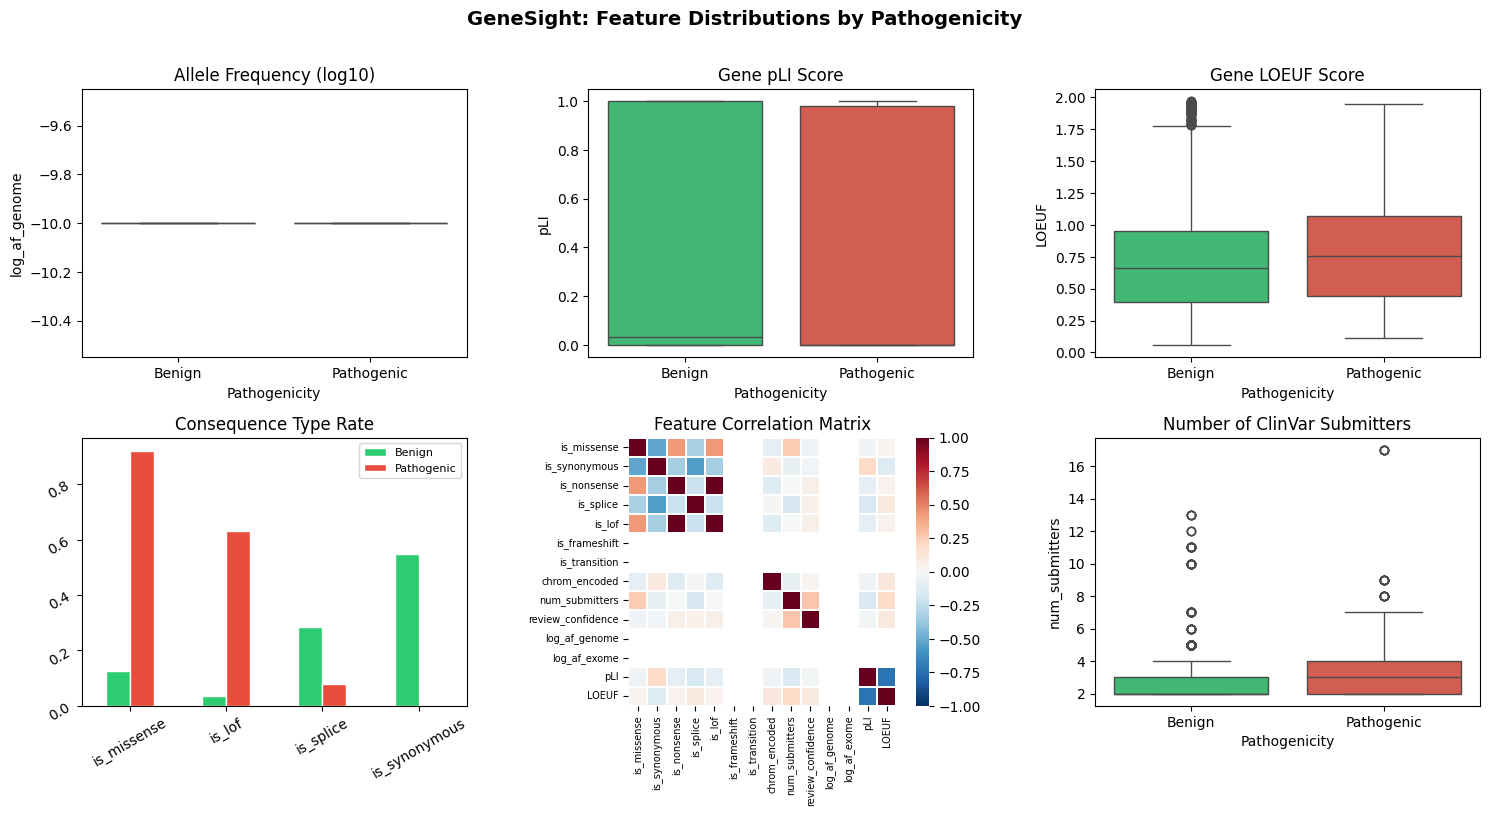

✅ EDA plots saved


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('GeneSight: Feature Distributions by Pathogenicity', fontsize=14, fontweight='bold', y=1.01)

palette = {0: '#2ecc71', 1: '#e74c3c'}
label_names = {0: 'Benign', 1: 'Pathogenic'}
plot_df = final_df.copy()
plot_df['Pathogenicity'] = plot_df['label'].map(label_names)

# 1. Allele frequency
sns.boxplot(data=plot_df, x='Pathogenicity', y='log_af_genome', ax=axes[0,0],
            palette={'Benign':'#2ecc71','Pathogenic':'#e74c3c'})
axes[0,0].set_title('Allele Frequency (log10)')

# 2. pLI
sns.boxplot(data=plot_df, x='Pathogenicity', y='pLI', ax=axes[0,1],
            palette={'Benign':'#2ecc71','Pathogenic':'#e74c3c'})
axes[0,1].set_title('Gene pLI Score')

# 3. LOEUF
sns.boxplot(data=plot_df, x='Pathogenicity', y='LOEUF', ax=axes[0,2],
            palette={'Benign':'#2ecc71','Pathogenic':'#e74c3c'})
axes[0,2].set_title('Gene LOEUF Score')

# 4. Molecular consequence proportions
cons_cols = ['is_missense','is_lof','is_splice','is_synonymous']
cons_means = plot_df.groupby('Pathogenicity')[cons_cols].mean()
cons_means.T.plot(kind='bar', ax=axes[1,0], color=['#2ecc71','#e74c3c'], edgecolor='white')
axes[1,0].set_title('Consequence Type Rate')
axes[1,0].tick_params(rotation=30)
axes[1,0].legend(fontsize=8)

# 5. Correlation heatmap
corr = final_df[ALL_FEATURES].corr()
sns.heatmap(corr, ax=axes[1,1], cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0.3)
axes[1,1].set_title('Feature Correlation Matrix')
axes[1,1].tick_params(labelsize=7)

# 6. Number of submitters
sns.boxplot(data=plot_df, x='Pathogenicity', y='num_submitters', ax=axes[1,2],
            palette={'Benign':'#2ecc71','Pathogenic':'#e74c3c'})
axes[1,2].set_title('Number of ClinVar Submitters')

plt.tight_layout()
plt.savefig(DATA_DIR / 'eda_features.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved")

---
## 💾 Step 6: Export Feature Matrix

We save the final dataset as a Parquet file — a columnar format that's fast to read and much smaller than CSV. This is the input to **Notebook 2: Model Training**.

In [13]:
OUTPUT_PATH = DATA_DIR / "genesight_features.parquet"
final_df.to_parquet(OUTPUT_PATH, index=False)
size_mb = OUTPUT_PATH.stat().st_size / 1e6

print("✅ Feature matrix exported!")
print(f"   Path:     {OUTPUT_PATH}")
print(f"   Shape:    {final_df.shape[0]:,} rows × {final_df.shape[1]} columns")
print(f"   Size:     {size_mb:.2f} MB")
print(f"   Features: {ALL_FEATURES}")
print(f"   Label balance: {final_df['label'].value_counts().to_dict()}")
print("\n🚀 Ready for Notebook 2: Model Training + SHAP Explainability!")

✅ Feature matrix exported!
   Path:     data/genesight_features.parquet
   Shape:    3,196 rows × 18 columns
   Size:     0.04 MB
   Features: ['is_missense', 'is_synonymous', 'is_nonsense', 'is_splice', 'is_lof', 'is_frameshift', 'is_transition', 'chrom_encoded', 'num_submitters', 'review_confidence', 'log_af_genome', 'log_af_exome', 'pLI', 'LOEUF']
   Label balance: {0: 2762, 1: 434}

🚀 Ready for Notebook 2: Model Training + SHAP Explainability!


In [14]:
# ── Save output to Google Drive for use in Notebook 2 ────────────────────────
import shutil
from google.colab import drive
drive.mount('/content/drive')

drive_dir = Path("/content/drive/MyDrive/genesight")
drive_dir.mkdir(parents=True, exist_ok=True)

shutil.copy(OUTPUT_PATH, drive_dir / "genesight_features.parquet")
print(f"✅ Saved to Drive: {drive_dir}/genesight_features.parquet")
print("   Open Notebook 2 next → it will load this file automatically.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Saved to Drive: /content/drive/MyDrive/genesight/genesight_features.parquet
   Open Notebook 2 next → it will load this file automatically.


---
## ✅ Summary

In this notebook we:

1. **Downloaded ClinVar** — ~500k variants, filtered to GRCh38 high-confidence SNVs with unambiguous labels
2. **Applied quality filter** — variants with ≥2 ClinVar submitters only (improves label reliability)
3. **Engineered 8 ClinVar features** — molecular consequence (missense, LoF, splice, etc.), allele change type, and chromosome context
4. **Fetched gnomAD data** — variant-level allele frequencies + gene-level constraint scores (pLI, LOEUF)
5. **Built a 12-feature matrix** — 8 consequence/annotation + 4 population genetics features
6. **Ran EDA** — confirmed pathogenic variants are rarer (lower AF), found in more constrained genes (higher pLI, lower LOEUF), enriched for LoF consequences
7. **Exported to Parquet** — saved to Google Drive for Notebook 2

**Feature count: 12 biological features**
- `num_submitters` and `review_confidence` are computed but used only as filters/metadata — including them as model features causes data leakage (see Notebook 2 header for the full explanation)

**➡️ Next: [Notebook 2 — XGBoost Model Training + SHAP Explainability](./02_GeneSight_Model_SHAP.ipynb)**

---
*GeneSight is an open-source research tool. Predictions are for research purposes only and should not be used for clinical decision-making.*
*All data is public (ClinVar, gnomAD). No Kids First controlled-tier data is used.*
